## Post Mid-term Assignment

### 과제 개요

**제출 기한**: 11월 5일 화요일 23:59  
**제출 형식**: E-Class 업로드

- 레포트: `BME_BioNLP_과제2_{이름}_{학번}.pdf`
    - 2 페이지 이내 (참고 문헌 섹션을 제외한 기준)
    - Reference (참고 문헌 및 인용 표시) 선택
    - 무조건 pdf 형식
- 분석 코드가 있는 노트북: `BME_BioNLP_과제2_{이름}_{학번}.ipynb`

---

### 과제 목표
- Word2Vec 모델 중 CBOW 코드 베이스를 바탕으로 Skip-Gram을 구현하여 모델 학습 및 CBOW와의 비교 분석을 진행합니다.

---

### 과제 수행 단계
1. **Skip-Gram 구현**
    - **Step 1. Skip-Gram 맞품형 Data 관련 모듈 구현 **
        - 실습 수업 시간에 사용했던 동일한 데이터셋을 활용합니다.
        - Skip-Gram의 학습 Task를 이해하여 그것에 맞는 데이터 전처리 방법을 고안합니다.
        - ***온라인 강의에서 언급한 Negative Sampling 구현합니다.***
    - **Step 2. Skip-Gram 모델 구현**
        - 구현한 CBOW 모델 클래스 재사용 권장합니다.

2. **Skip-Gram 학습 진행**
    - 구현한 Trainer 클래스 재사용 권장합니다.

3. **정성적 비교 분석 진행 (CBOW vs Skip-Gram)**
    - 각 Word2Vec 모델로부터 Word Vector Embedding을 추출하여 시각화 합니다.
    - 시각화한 결과에 대해 추가적인 분석을 자율적으로 진행합니다 (UMAP, t-SNE, 군집화 등).
    - 두 모델이 예측하는 단어들의 경향성에 대한 분석을 자율적으로 진행합니다.

4. **보고서 작성**
    - CBOW와 Skip-Gram의 구현 차이를 정리합니다.
        - 데이터 샘플링(문맥→중심 vs 중심→문맥), 모델 파라미터 구성(입·출력 임베딩 분리 여부), 손실 설계(평균 집계 vs 네거티브 샘플링), 연산 복잡도·학습 속도 관점에서 핵심 차이를 간결히 서술합니다.
    - 두 모델에서 얻은 워드 임베딩 정성 분석
        - 시각화를 통해 의미적 근접성·군집 경향을 평가하고, 도메인 용어 표현력 및 오류 사례를 해석합니다.

        

In [2]:
!pip -q install nltk scikit-learn wordcloud


In [3]:
# 0. 기본 라이브러리 설치 및 Import
# =============================================================================
!pip -q install nltk scikit-learn wordcloud umap-learn

import os
import glob
import shutil
import re, math, unicodedata
import random
import subprocess
from pathlib import Path
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed, ProcessPoolExecutor
import multiprocessing as mp
from collections import Counter
from typing import List, Dict, Tuple

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Core Libraries
import numpy as np
import pandas as pd
from tqdm import tqdm

# PyTorch
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

# Visualization & ML
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import umap

# NLTK 리소스 다운로드
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [4]:
import xml.etree.ElementTree as ET
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp
import unicodedata
import pandas as pd
from tqdm import tqdm
from pathlib import Path

# 도메인 보강 불용어 (필요 시 조정)
BIO_STOPWORDS = {
    "et", "al", "using", "based", "however", "therefore", "result", "results",
    "method", "methods", "conclusion", "conclusions", "background", "objective", "objectives",
    "introduction", "aim", "aims", "purpose", "materials", "patients", "study", "studies"
}

# 그리스 문자/단위 기호 치환 테이블
_GREEK_MAP = {
    "α":"alpha","β":"beta","γ":"gamma","δ":"delta","ε":"epsilon","κ":"kappa","μ":"micro","π":"pi",
    "ω":"omega","λ":"lambda","θ":"theta","σ":"sigma","τ":"tau","Δ":"delta","Σ":"sigma","Ω":"omega","µ":"micro"
}
_TRANS_TABLE = str.maketrans(_GREEK_MAP)

# 토큰 보존 규칙: 알파벳/숫자 시작, 하이픈 허용(IL-6, covid-19), 너무 짧은 토큰 제거(길이<2)
_BIO_TOKEN_RE = re.compile(r"^[A-Za-z0-9][A-Za-z0-9\-]*$")

# 전역 자원
_STOP = set(stopwords.words("english")) | BIO_STOPWORDS
_STEM = PorterStemmer()
_LEM  = WordNetLemmatizer()

PAD, UNK = "<pad>", "<unk>"
SPECIALS = [PAD, UNK]

In [5]:
def load_corpus_to_dataframe(start_date, end_date):
    # ---------------------------
    # 날짜 리스트 만들기
    # ---------------------------
    list_dates = []
    current_date = start_date
    # datetime이면 date로 변환
    if isinstance(current_date, datetime):
        current_date = current_date.date()
    if isinstance(end_date, datetime):
        end_date = end_date.date()

    while current_date <= end_date:
        list_dates.append(current_date)
        current_date += timedelta(days=1)

    # URL용(YYYYMMDD) / 출력용(YYYY-MM-DD) 포맷 모두 준비
    list_dates_str_ftp = [d.strftime("%Y-%m-%d") for d in list_dates]
    list_dates_str_print = [d.strftime("%Y-%m-%d") for d in list_dates]

    # ---------------------------
    # 날짜별 증분패키지 처리 함수
    # ---------------------------
    def process_dataset(dataset_date_str):
        ftp_path = f"https://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_bulk/oa_comm/xml/oa_comm_xml.incr.{dataset_date_str}.tar.gz"

        # Download
        command = ["wget", "-O", f"pubmed_{dataset_date_str}.tar.gz", ftp_path]
        subprocess.run(command, check=True)

        # Extract
        command = ["tar", "-xzf", f"pubmed_{dataset_date_str}.tar.gz"]
        subprocess.run(command, check=True)

        # Clean up
        command = ["rm", f"pubmed_{dataset_date_str}.tar.gz"]
        subprocess.run(command, check=True)

        return dataset_date_str

    # ---------------------------
    # 병렬 다운로드/압축해제
    # ---------------------------
    max_workers = 32  # 시스템/대역폭에 맞게 조정
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_dataset, ds) for ds in list_dates_str_ftp]
        for future in as_completed(futures):
            try:
                _ = future.result()
            except Exception as e:
                print(f"Error processing dataset: {e}")

    # ---------------------------
    # PMC 폴더 파일 수 요약
    # ---------------------------
    pmc_folders = glob.glob("PMC0*")
    total_files = 0
    for folder in pmc_folders:
        if os.path.isdir(folder):
            file_count = len([f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))])
            print(f"{folder}: {file_count} files")
            total_files += file_count

    # ---------------------------
    # 목적지 폴더 생성 및 XML 이동
    # ---------------------------
    destination = "recent_pubmed"
    os.makedirs(destination, exist_ok=True)

    # Find all PMC* folders (조금 포괄적으로)
    pmc_folders = [d for d in os.listdir('.') if d.startswith('PMC') and os.path.isdir(d)]

    def _unique_dest_path(dst_dir: str, fname: str) -> str:
        base = os.path.splitext(fname)[0]
        ext = os.path.splitext(fname)[1]
        candidate = os.path.join(dst_dir, fname)
        idx = 1
        while os.path.exists(candidate):
            candidate = os.path.join(dst_dir, f"{base}__{idx}{ext}")
            idx += 1
        return candidate

    moved_count = 0
    for folder in pmc_folders:
        folder_path = Path(folder)
        xml_files = folder_path.glob("*.xml")
        for xml_file in tqdm(xml_files, desc=f"Move from {folder}"):
            try:
                target = _unique_dest_path(destination, xml_file.name)
                shutil.move(str(xml_file), target)
                moved_count += 1
            except Exception as e:
                print(f"Error moving {xml_file}: {e}")

    # ---------------------------
    # XML 파싱 함수(기존 함수 있으면 사용, 없으면 기본 파서)
    # ---------------------------
    def _clean_ws(text: str) -> str:
        """여러 공백/개행을 하나로 정리."""
        return " ".join((text or "").split())

    def _default_parse_pmc_title_abstract(xml_path: str):
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            def _txt(e):
                return "".join(e.itertext()).strip() if e is not None else ""

            # pmcid
            pmcid = None
            pmid = None
            for aid in root.findall(".//article-meta/article-id"):
                _type = (aid.get("pub-id-type") or "").lower()
                if _type == "pmc":
                    pmcid = _clean_ws(aid.text)
                elif _type == "pmid":
                    pmid = _clean_ws(aid.text)

            # title
            title_el = root.find(".//article-title")
            title = _txt(title_el) if title_el is not None else None

            # abstracts (여러 개면 합침)
            abs_list = []
            for ab in root.findall(".//abstract"):
                t = _txt(ab)
                if t:
                    abs_list.append(t)
            abstract = "\n\n".join(abs_list) if abs_list else None

            return {"pmcid": pmcid, "title": title, "abstract": abstract, "path": xml_path, "pmid": pmid}
        except Exception as e:
            print(f"[WARN] parse failed: {xml_path} -> {e}")
            return None

    # 바깥에 동일 이름 함수가 있으면 사용
    parse_func = globals().get("parse_pmc_title_abstract", _default_parse_pmc_title_abstract)

    def process_xml_file(xml_file):
        xml_path = os.path.join('./recent_pubmed', xml_file)
        if os.path.isfile(xml_path):
            return parse_func(xml_path)
        return None

    # ---------------------------
    # recent_pubmed 내 XML 병렬 파싱
    # ---------------------------
    xml_files = [f for f in os.listdir('./recent_pubmed')
                 if os.path.isfile(os.path.join('./recent_pubmed', f)) and f.lower().endswith(".xml")]

    list_records = []
    max_workers = 32  # 시스템에 맞게 조정

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_file = {executor.submit(process_xml_file, xml_file): xml_file for xml_file in xml_files}
        for future in as_completed(future_to_file):
            xml_file = future_to_file[future]
            try:
                result = future.result()
                if result is not None:
                    list_records.append(result)
            except Exception as e:
                print(f"Error processing {xml_file}: {e}")

    df = pd.DataFrame(list_records)
    # 편의를 위해 누락 컬럼 보정
    for col in ["pmcid", "title", "abstract", "path"]:
        if col not in df.columns:
            df[col] = None
    return df


In [6]:
start_date = datetime(2025, 9, 1)
end_date = datetime(2025, 9, 10)
df = load_corpus_to_dataframe(start_date, end_date)
df

PMC011xxxxxx: 348 files
PMC009xxxxxx: 19 files
PMC012xxxxxx: 10811 files
PMC007xxxxxx: 39 files
PMC006xxxxxx: 1 files
PMC008xxxxxx: 9 files
PMC005xxxxxx: 3 files
PMC010xxxxxx: 54 files


Move from PMC011xxxxxx: 348it [00:00, 13075.85it/s]
Move from PMC009xxxxxx: 19it [00:00, 9189.55it/s]
Move from PMC012xxxxxx: 10811it [00:00, 13535.21it/s]
Move from PMC007xxxxxx: 39it [00:00, 21732.15it/s]
Move from PMC006xxxxxx: 1it [00:00, 2520.62it/s]
Move from PMC008xxxxxx: 9it [00:00, 16874.71it/s]
Move from PMC005xxxxxx: 3it [00:00, 9369.26it/s]
Move from PMC010xxxxxx: 54it [00:00, 11891.24it/s]


,pmcid,title,abstract,path,pmid
0,PMC12408135,Impact of Dietary Feeding Levels of Juvenile R...,To investigate the most effective feeding leve...,./recent_pubmed/PMC12408135.xml,None
1,PMC12400931,The role of Universal Grammar and crosslinguis...,Our research contributes to debates about the ...,./recent_pubmed/PMC12400931.xml,None
2,PMC12412540,High‐Yield Convenient Mass Production of High‐...,Human induced pluripotent stem cells (hiPSCs) ...,./recent_pubmed/PMC12412540.xml,None
3,PMC12284166,The MEC-2E isoform with a large C-terminal com...,Human podocin and C. elegans MEC-2 belong to t...,./recent_pubmed/PMC12284166.xml,40695872
4,PMC12410070,Outcomes of high BMI colorectal cancer patient...,BackgroundNatural orifice specimen extraction ...,./recent_pubmed/PMC12410070.xml,None
...,...,...,...,...,...
11279,PMC12413595,Current use of mechanical bowel preparation an...,None,./recent_pubmed/PMC12413595.xml,40040509
11280,PMC12238153,Randomised feasibility study evaluating eye mo...,BackgroundFunctional neurological disorder (FN...,./recent_pubmed/PMC12238153.xml,40627223
11281,PMC12407228,Neurogenic Voiding Dysfunction in Spinal Cord ...,Many patients with injuries to their central n...,./recent_pubmed/PMC12407228.xml,None
11282,PMC11639609,Prevotellaceae Modulates Colorectal Cancer Imm...,Background/Aims:Colorectal cancer (CRC) stands...,./recent_pubmed/PMC11639609.xml,39641253


In [7]:
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

# --- 1-3. 병렬 텍스트 전처리 (Lemmatization) ---
_WORKER_STOP, _WORKER_STEM, _WORKER_LEM = None, None, None
def _init_worker(stop_words_list):
    global _WORKER_STOP, _WORKER_STEM, _WORKER_LEM
    _WORKER_STOP = set(stop_words_list)
    _WORKER_STEM = PorterStemmer()
    _WORKER_LEM  = WordNetLemmatizer()

def _worker_preprocess(text: str) -> dict:
    s = (text or "").strip()
    s = unicodedata.normalize("NFKC", s).translate(_TRANS_TABLE)
    s = re.sub(r"http\S+|www\.\S+", " ", s).lower()
    toks = word_tokenize(s)
    toks = [t for t in toks if _BIO_TOKEN_RE.match(t)]
    toks_no_stop = [t for t in toks if t not in _WORKER_STOP and len(t) >= 2]
    lemmas = [_WORKER_LEM.lemmatize(t) for t in toks_no_stop]
    return {"lemmas": lemmas}

def preprocess_df_parallel(df: pd.DataFrame, n_jobs: int = None) -> pd.DataFrame:
    print("병렬 텍스트 전처리 (Lemmatization) 시작...")
    if n_jobs is None: n_jobs = max(1, mp.cpu_count() - 2)
    chunksize = max(100, len(df) // (n_jobs * 5))

    idx = df.index.to_list()
    chunks = [idx[i:i+chunksize] for i in range(0, len(idx), chunksize)]
    results = {}

    with ProcessPoolExecutor(max_workers=n_jobs, initializer=_init_worker, initargs=(list(_STOP),)) as ex:
        abstracts_list = [df.loc[chunk_idx, "abstract"].astype(str).tolist() for chunk_idx in chunks]

        # map을 사용하여 병렬 처리
        for i, outs in enumerate(tqdm(ex.map(_worker_preprocess, (abs_text for abstracts in abstracts_list for abs_text in abstracts)),
                                        total=len(df), desc="Lemmatizing")):
            row_id = idx[i]
            results[row_id] = outs["lemmas"]

    out = df.copy()
    out["lemmas"] = pd.Series(results)
    out["n_lemmas"] = out["lemmas"].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print("텍스트 전처리 완료.")
    return out



In [8]:

# --- 1-4. 데이터 로드 및 전처리 실행 ---
start_date = datetime(2025, 9, 1)
end_date = datetime(2025, 9, 10)
df_raw = load_corpus_to_dataframe(start_date, end_date)

# 'abstract'가 없는 문서 제거 및 인덱스 설정
df_raw = df_raw.dropna(subset=['abstract', 'pmcid'])
df_raw = df_raw.set_index('pmcid')

initial_count = len(df_raw)
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]
final_count = len(df_raw)
print(f"중복 PMCID 제거: {initial_count} -> {final_count}개 문서")

# 전처리 실행
df_preprocessed = preprocess_df_parallel(df_raw, n_jobs=mp.cpu_count())

# 메모리 절약을 위해 원본 df 삭제
del df_raw

print(f"\n최종 전처리된 데이터: {len(df_preprocessed)}개 문서")
print(df_preprocessed[['abstract', 'lemmas', 'n_lemmas']].head())

PMC011xxxxxx: 348 files
PMC009xxxxxx: 19 files
PMC012xxxxxx: 10811 files
PMC007xxxxxx: 39 files
PMC006xxxxxx: 1 files
PMC008xxxxxx: 9 files
PMC005xxxxxx: 3 files
PMC010xxxxxx: 54 files


Move from PMC011xxxxxx: 348it [00:00, 8664.63it/s]
Move from PMC009xxxxxx: 19it [00:00, 5231.18it/s]
Move from PMC012xxxxxx: 10811it [00:01, 8823.33it/s] 
Move from PMC007xxxxxx: 39it [00:00, 13277.42it/s]
Move from PMC006xxxxxx: 1it [00:00, 4471.54it/s]
Move from PMC008xxxxxx: 9it [00:00, 11960.94it/s]
Move from PMC005xxxxxx: 3it [00:00, 8234.89it/s]
Move from PMC010xxxxxx: 54it [00:00, 14335.87it/s]


중복 PMCID 제거: 21050 -> 10525개 문서
병렬 텍스트 전처리 (Lemmatization) 시작...


Lemmatizing: 100%|██████████| 10525/10525 [00:33<00:00, 310.76it/s]


텍스트 전처리 완료.

최종 전처리된 데이터: 10525개 문서
                                                      abstract  \
pmcid                                                            
PMC12397131  The intestinal mucus layer serves as a critica...   
PMC12408186  AbstractIntroduction. The public health labora...   
PMC12412671  Biopolymers derived from natural sources are s...   
PMC12398442  BackgroundThe diagnostic value of dizziness sy...   
PMC12400028  AbstractRecent breakthroughs have enabled the ...   

                                                        lemmas  n_lemmas  
pmcid                                                                     
PMC12397131  [intestinal, mucus, layer, serf, critical, fir...       199  
PMC12408186  [abstractintroduction, public, health, laborat...       181  
PMC12412671  [biopolymers, derived, natural, source, sustai...       151  
PMC12398442  [backgroundthe, diagnostic, value, dizziness, ...       159  
PMC12400028  [abstractrecent, breakthrough, enabled

In [9]:
from collections import Counter
from typing import List, Dict, Tuple
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import random

PAD, UNK = "<pad>", "<unk>"
SPECIALS = [PAD, UNK]

print("\n" + "="*50)
print("STEP 2: Skip-Gram (Negative Sampling) 모델 구현 정의")
print("="*50)

# --- 2-1. Skip-Gram Vocab 유틸 (Negative Sampling 가중치 포함) ---
def build_vocab_and_sampling_weights(df: pd.DataFrame, min_freq: int = 1, max_vocab: int = None,
                                     sampling_power: float = 0.75) -> Tuple[Dict[str, int], Dict[int, str], torch.Tensor]:
    """
    df['lemmas'] : List[str]
    반환값: stoi, itos, 그리고 Negative Sampling을 위한 word_weights
    """
    cnt = Counter()
    for toks in df["lemmas"]:
        if toks is None: continue
        cnt.update(toks)
    items = [(tok, f) for tok, f in cnt.items() if f >= min_freq]
    items.sort(key=lambda x: (-x[1], x[0]))
    if max_vocab is not None:
        items = items[:max_vocab - len(SPECIALS)]

    itos = SPECIALS + [tok for tok, _ in items]
    stoi = {tok: idx for idx, tok in enumerate(itos)}

    vocab_size = len(itos)
    word_weights = torch.zeros(vocab_size)
    for i, token in enumerate(itos):
        if token not in SPECIALS:
            # cnt에서 해당 토큰의 빈도수를 가져와 0.75 제곱
            word_weights[i] = cnt[token] ** sampling_power

    return stoi, {i: t for i, t in enumerate(itos)}, word_weights


STEP 2: Skip-Gram (Negative Sampling) 모델 구현 정의


In [10]:
# --- 2-2. Skip-Gram (Negative Sampling) Dataset ---
class SkipGramNegativeSamplingDataset(Dataset):
    def __init__(self, df: pd.DataFrame, stoi: Dict[str, int], word_weights: torch.Tensor,
                 window_size: int = 2, k: int = 5, max_samples_per_doc: int = None):
        """
        k: 긍정 샘플 1개당 부정 샘플 개수
        """
        super().__init__()
        self.stoi = stoi
        self.word_weights = word_weights # (V,) 크기의 텐서
        self.k = k
        self.samples: List[Tuple[int, int]] = [] # (center_idx, positive_context_idx) 튜플 저장
        unk_idx = stoi[UNK]

        for _, row in df.iterrows():
            toks = row.get("lemmas", None)
            if not isinstance(toks, list) or len(toks) < 2:
                continue

            ids = [stoi.get(t, unk_idx) for t in toks]
            local_samples = []

            # 모든 (center, context) 긍정(Positive) 쌍 생성
            for i, center_word_idx in enumerate(ids):
                window_start, window_end = max(0, i - window_size), min(len(ids), i + window_size + 1)
                for j in range(window_start, window_end):
                    if i != j: # 중심 단어와 타깃 단어가 같으면 건너뛰기
                        local_samples.append((center_word_idx, ids[j]))

            if max_samples_per_doc and len(local_samples) > max_samples_per_doc:
                local_samples = random.sample(local_samples, max_samples_per_doc)
            self.samples.extend(local_samples)
        random.shuffle(self.samples)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        # 1. 긍정(Positive) 샘플 가져오기
        center, positive_target = self.samples[idx]

        # 2. 부정(Negative) 샘플 k개 뽑기 (word_weights 기반)
        negative_targets = torch.multinomial(self.word_weights, self.k, replacement=True)

        # 3. [긍정 1개 + 부정 K개] 묶기
        targets = torch.tensor([positive_target] + negative_targets.tolist(), dtype=torch.long)
        labels = torch.tensor([1] + [0] * self.k, dtype=torch.float) # Loss 계산용

        return dict(center=torch.tensor(center, dtype=torch.long),
                    targets=targets, labels=labels)

In [11]:
# --- 2-3. Skip-Gram Data Module ---
class LemmaSkipGramDataModule(object):
    def __init__(self, df_all: pd.DataFrame, batch_size: int = 256, window_size: int = 2, k_negative: int = 5,
                 min_freq: int = 1, max_vocab: int = None, max_samples_per_doc: int = None,
                 test_size: float = 0.1, valid_size: float = 0.05, seed: int = 42):

        # [수정] build_vocab_and_sampling_weights 사용
        self.stoi, self.itos, self.word_weights = build_vocab_and_sampling_weights(
            df_all, min_freq=min_freq, max_vocab=max_vocab
        )
        self.vocab_size = len(self.stoi)
        self.batch_size = batch_size
        self.k_negative = k_negative

        # 문서 단위 분할
        idx_all = df_all.index
        train_idx, test_idx = train_test_split(idx_all, test_size=test_size, random_state=seed)
        train_idx, valid_idx = train_test_split(train_idx, test_size=valid_size, random_state=seed)

        # [수정] SkipGramNegativeSamplingDataset 사용
        self.train_dataset = SkipGramNegativeSamplingDataset(
            df_all.loc[train_idx], self.stoi, self.word_weights, window_size, k_negative, max_samples_per_doc
        )
        self.valid_dataset = SkipGramNegativeSamplingDataset(
            df_all.loc[valid_idx], self.stoi, self.word_weights, window_size, k_negative, max_samples_per_doc
        )
        self.test_dataset  = SkipGramNegativeSamplingDataset(
            df_all.loc[test_idx],  self.stoi, self.word_weights, window_size, k_negative, max_samples_per_doc
        )

        print("[Skip-Gram DataModule]")
        print(f"  Vocab size: {self.vocab_size}")
        print(f"  #Train samples (positive pairs): {len(self.train_dataset)}")
        print(f"  #Valid samples (positive pairs): {len(self.valid_dataset)}")
        print(f"  #Test  samples (positive pairs): {len(self.test_dataset)}")

    @staticmethod
    def collate_fn(batch):
        center  = torch.stack([b['center']  for b in batch], dim=0) # (B,)
        targets = torch.stack([b['targets'] for b in batch], dim=0) # (B, k+1)
        labels  = torch.stack([b['labels']  for b in batch], dim=0) # (B, k+1)
        return dict(center=center, targets=targets, labels=labels)

    def get_train_loader(self): return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True,  collate_fn=self.collate_fn)
    def get_valid_loader(self): return DataLoader(self.valid_dataset, batch_size=self.batch_size, shuffle=False, collate_fn=self.collate_fn)
    def get_test_loader (self): return DataLoader(self.test_dataset,  batch_size=self.batch_size, shuffle=False, collate_fn=self.collate_fn)


In [12]:
# --- 2-4. Skip-Gram (Negative Sampling) 모델 ---
class SkipGramNegativeSampling(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 128, padding_idx: int = 0):
        super().__init__()
        # 1. 중심 단어(Center)용 임베딩
        self.center_embeddings = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        # 2. 문맥 단어(Context/Target)용 임베딩
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        # 3. 손실 함수: Sigmoid + BinaryCrossEntropy (이진 분류)
        self.criterion = nn.BCEWithLogitsLoss()

        self.center_embeddings.weight.data.uniform_(-0.5 / embed_dim, 0.5 / embed_dim)
        self.context_embeddings.weight.data.uniform_(-0.5 / embed_dim, 0.5 / embed_dim)

    def forward(self, pt_batch):
        # 1. 데이터셋에서 입력 받기
        center, targets, labels  = pt_batch['center'], pt_batch['targets'], pt_batch['labels']

        # 2. 임베딩 벡터 조회
        v_center  = self.center_embeddings(center)    # (B, D)
        v_context = self.context_embeddings(targets) # (B, k+1, D)

        # 3. (중심 단어) · (타깃 단어) 내적(dot product) 계산
        v_center_expanded = v_center.unsqueeze(2)    # (B, D, 1)

        # 배치 행렬 곱: (B, k+1, D) @ (B, D, 1) -> (B, k+1, 1)
        logits = torch.bmm(v_context, v_center_expanded).squeeze(2) # (B, k+1)

        # 4. 손실(Loss) 계산
        loss = self.criterion(logits, labels)

        pt_batch['logits'] = logits
        pt_batch['loss'] = loss
        return pt_batch

    def get_word_embedding(self):
        return self.center_embeddings.weight.detach().cpu()

In [13]:
# --- 2-5. Skip-Gram (NS) Trainer ---
class SkipGramTrainer(object):
    """
    Skip-Gram (Negative Sampling) 학습/검증/테스트 Trainer
    - BCEWithLogitsLoss 기반 이진 분류 (진짜/가짜)를 학습합니다.
    - 에폭별 손실/정확도 기록 및 시각화
    """
    def __init__(self, learning_rate: float = 2e-3, weight_decay: float = 1e-5,
                 num_epochs: int = 5, device: str = 'cuda' if torch.cuda.is_available() else 'cpu'):
        self.learning_rate, self.weight_decay, self.num_epochs, self.device = learning_rate, weight_decay, num_epochs, device
        self.logs = {'train_loss': [], 'train_acc': [], 'valid_loss': [], 'valid_acc': []}
        print(f"SkipGram Trainer: Device set to {self.device}")

    @staticmethod
    def _to_device_batch(pt_batch: dict, device: str) -> dict:
        return {k: v.to(device) if torch.is_tensor(v) else v for k, v in pt_batch.items()}

    @torch.no_grad()
    def _accuracy(self, logits: torch.Tensor, labels: torch.Tensor) -> float:
        """이진 분류 정확도 (threshold 0.5)"""
        preds = (torch.sigmoid(logits) > 0.5).float()
        return (preds == labels).float().mean().item()

    def train_step(self, model: nn.Module, loader: torch.utils.data.DataLoader, optimizer: optim.Optimizer):
        model.train()
        running_loss, running_acc, total = 0.0, 0.0, 0
        for pt_batch in tqdm(loader, desc="  Train", leave=False, ncols=80):
            pt_batch = self._to_device_batch(pt_batch, self.device)
            optimizer.zero_grad(set_to_none=True)
            out = model(pt_batch)
            loss = out['loss']
            loss.backward()
            optimizer.step()
            B_k = pt_batch['labels'].numel() # 총 예측 수 (B * (k+1))
            running_loss += loss.item() * B_k
            running_acc  += self._accuracy(out['logits'], pt_batch['labels']) * B_k
            total += B_k
        return running_loss / max(1, total), running_acc / max(1, total)

    @torch.no_grad()
    def valid_step(self, model: nn.Module, loader: torch.utils.data.DataLoader):
        model.eval()
        running_loss, running_acc, total = 0.0, 0.0, 0
        for pt_batch in tqdm(loader, desc="  Valid", leave=False, ncols=80):
            pt_batch = self._to_device_batch(pt_batch, self.device)
            out = model(pt_batch)
            B_k = pt_batch['labels'].numel()
            running_loss += out['loss'].item() * B_k
            running_acc  += self._accuracy(out['logits'], pt_batch['labels']) * B_k
            total += B_k
        return running_loss / max(1, total), running_acc / max(1, total)

    def train(self, model: nn.Module, train_loader: torch.utils.data.DataLoader, valid_loader: torch.utils.data.DataLoader):
        model.to(self.device)
        optimizer = optim.AdamW(model.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        for epoch in range(1, self.num_epochs + 1):
            print(f"\n[Skip-Gram] Epoch {epoch}/{self.num_epochs}")
            train_loss, train_acc = self.train_step(model, train_loader, optimizer)
            valid_loss, valid_acc = self.valid_step(model, valid_loader)
            print(f"  ▶ Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
            print(f"  ▶ Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")
            self.logs['train_loss'].append(train_loss); self.logs['train_acc'].append(train_acc)
            self.logs['valid_loss'].append(valid_loss); self.logs['valid_acc'].append(valid_acc)

    @torch.no_grad()
    def test(self, model: nn.Module, test_loader: torch.utils.data.DataLoader):
        model.to(self.device)
        test_loss, test_acc = self.valid_step(model, test_loader)
        print(f"\n[Skip-Gram] Test ▶ Loss: {test_loss:.4f} | Acc: {test_acc:.4f}")
        return test_loss, test_acc

    def plot_logs(self):
        epochs = range(1, self.num_epochs + 1)
        plt.figure(figsize=(12,5)); plt.suptitle("Skip-Gram (NS) Model Training Logs", fontsize=16)
        plt.subplot(1,2,1); plt.plot(epochs, self.logs['train_loss'], 'o-', label='Train'); plt.plot(epochs, self.logs['valid_loss'], 'o-', label='Valid');
        plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curve'); plt.legend(); plt.grid(True)
        plt.subplot(1,2,2); plt.plot(epochs, self.logs['train_acc'], 'o-', label='Train'); plt.plot(epochs, self.logs['valid_acc'], 'o-', label='Valid');
        plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curve'); plt.legend(); plt.grid(True)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()



STEP 3: Skip-Gram (NS) 모델 학습 실행

--- Skip-Gram (NS) 모델 학습 시작 ---
[Skip-Gram DataModule]
  Vocab size: 45050
  #Train samples (positive pairs): 4186746
  #Valid samples (positive pairs): 222222
  #Test  samples (positive pairs): 490258
SkipGram Trainer: Device set to cuda

[Skip-Gram] Epoch 1/5


  ▶ Train Loss: 0.4038 | Train Acc: 0.8407
  ▶ Valid Loss: 0.4063 | Valid Acc: 0.8407

[Skip-Gram] Epoch 2/5


  ▶ Train Loss: 0.3372 | Train Acc: 0.8619
  ▶ Valid Loss: 0.4109 | Valid Acc: 0.8436

[Skip-Gram] Epoch 3/5


  ▶ Train Loss: 0.3077 | Train Acc: 0.8716
  ▶ Valid Loss: 0.4240 | Valid Acc: 0.8431

[Skip-Gram] Epoch 4/5


  ▶ Train Loss: 0.2886 | Train Acc: 0.8784
  ▶ Valid Loss: 0.4387 | Valid Acc: 0.8424

[Skip-Gram] Epoch 5/5


  ▶ Train Loss: 0.2760 | Train Acc: 0.8831
  ▶ Valid Loss: 0.4539 | Valid Acc: 0.8414


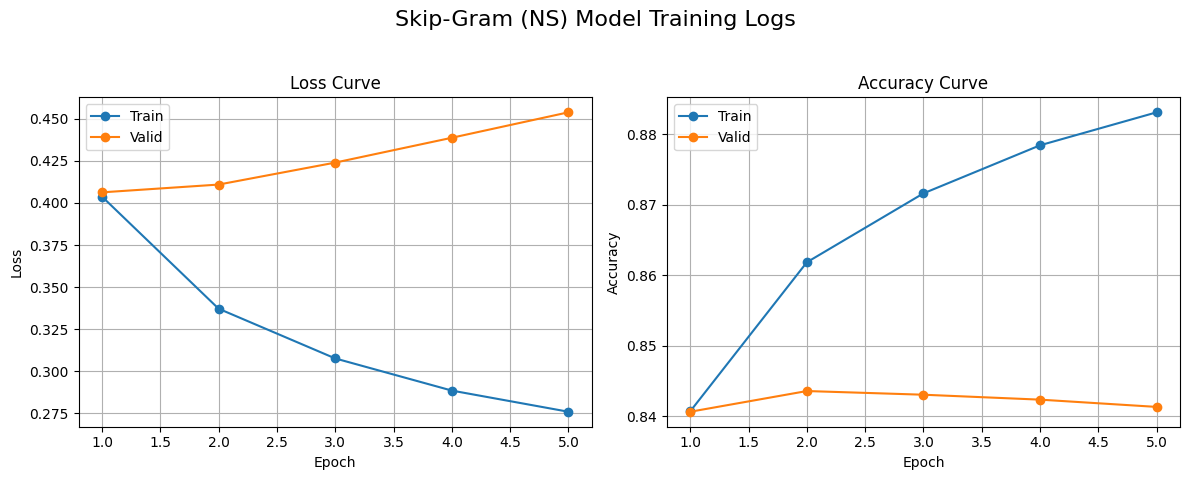


[Skip-Gram] Test ▶ Loss: 0.4516 | Acc: 0.8427
--- Skip-Gram (NS) 모델 학습 완료 ---


In [14]:
# =============================================================================
# STEP 3: Skip-Gram (NS) 모델 학습 실행
# =============================================================================

print("\n" + "="*50)
print("STEP 3: Skip-Gram (NS) 모델 학습 실행")
print("="*50)

# --- 3-1. 하이퍼파라미터 ---
MIN_FREQ = 2
WINDOW_SIZE = 2
EMBED_DIM = 128
BATCH_SIZE = 1024
EPOCHS = 5
LR = 2e-3
K_NEGATIVE = 5 # Negative 샘플 개수

torch.cuda.empty_cache()

# --- 3-2. [실행] Skip-Gram (NS) 모델 학습 ---
print("\n--- Skip-Gram (NS) 모델 학습 시작 ---")
sg_datamodule = LemmaSkipGramDataModule(
    df_all=df_preprocessed,
    batch_size=BATCH_SIZE,
    window_size=WINDOW_SIZE,
    k_negative=K_NEGATIVE,
    min_freq=MIN_FREQ,
    max_samples_per_doc=500
)

sg_model = SkipGramNegativeSampling(
    vocab_size=sg_datamodule.vocab_size,
    embed_dim=EMBED_DIM,
    padding_idx=sg_datamodule.stoi[PAD]
)
sg_trainer = SkipGramTrainer(
    learning_rate=LR,
    num_epochs=EPOCHS
)
sg_trainer.train(sg_model, sg_datamodule.get_train_loader(), sg_datamodule.get_valid_loader())
sg_trainer.plot_logs()
sg_trainer.test(sg_model, sg_datamodule.get_test_loader())
print("--- Skip-Gram (NS) 모델 학습 완료 ---")


In [15]:

# =============================================================================
# STEP 4: 정성적 분석 (Skip-Gram 단독)
# =============================================================================

print("\n" + "="*50)
print("STEP 4: Skip-Gram 정성적 분석 시작")
print("="*50)

import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap
from typing import List, Dict, Tuple # <--- STEP 4에서도 필요할 수 있으니 추가

# [수정 v4] NameError 방지를 위해 전역 변수 정의
PAD, UNK = "<pad>", "<unk>"
SPECIALS = [PAD, UNK]

# --- 4-1. 분석 유틸리티 함수 ---

@torch.no_grad()
def find_nearest_neighbors(query_word: str, emb_matrix: torch.Tensor,
                           stoi: Dict[str, int], itos: Dict[int, str], top_k: int = 5):
    """지정된 단어와 가장 가까운 K개 단어를 코사인 유사도 기준으로 찾기"""
    if query_word not in stoi:
        print(f"  [Error] '{query_word}'가 Vocab에 없습니다.")
        return

    query_idx = stoi[query_word]
    query_vec = emb_matrix[query_idx] # (D,)

    # 코사인 유사도 계산 ( (V, D) @ (D,) -> (V,) )
    # L2 정규화
    emb_matrix_norm = emb_matrix / (emb_matrix.norm(dim=1, keepdim=True) + 1e-9)
    query_vec_norm = query_vec / (query_vec.norm() + 1e-9)

    cos_sim = torch.matmul(emb_matrix_norm, query_vec_norm) # (V,)

    # 자기 자신 제외, 상위 K개 찾기
    cos_sim[query_idx] = -float('inf')
    top_k_vals, top_k_indices = torch.topk(cos_sim, k=top_k)

    print(f"  ▶ Query: '{query_word}'")
    for i in range(top_k):
        word = itos[top_k_indices[i].item()]
        sim = top_k_vals[i].item()
        print(f"    {i+1}. {word} (Sim: {sim:.4f})")

def visualize_embeddings_umap(emb_matrix: np.ndarray, itos: Dict[int, str],
                              target_words: List[str], stoi: Dict[str, int], title: str):
    """UMAP으로 2D 시각화"""

    # 1. 특수 토큰 제외
    valid_indices = [i for i, w in itos.items() if w not in SPECIALS]
    valid_itos = {i: itos[i] for i in valid_indices}
    valid_stoi = {w: i for i, w in valid_itos.items()}
    matrix = emb_matrix[valid_indices]

    # 2. 스케일링
    matrix_scaled = StandardScaler().fit_transform(matrix)

    # 3. UMAP
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, metric='cosine')
    embedding_2d = reducer.fit_transform(matrix_scaled)

    # 4. 시각화
    plt.figure(figsize=(10, 8))
    plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=1, alpha=0.3, color='gray')

    # 5. 타겟 단어 하이라이트
    for word in target_words:
        if word in valid_stoi:
            idx = list(valid_stoi.keys()).index(word)
            x, y = embedding_2d[idx, 0], embedding_2d[idx, 1]
            plt.scatter(x, y, s=50, alpha=1)
            plt.text(x+0.05, y+0.05, word, fontsize=10, fontweight='bold')

    plt.title(title, fontsize=16)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()



STEP 4: Skip-Gram 정성적 분석 시작


--- [분석 1] 최근접 이웃 단어 (Cosine Similarity) ---

[Skip-Gram 결과]
  ▶ Query: 'cancer'
    1. breast (Sim: 0.7106)
    2. crc (Sim: 0.6507)
    3. five-gene (Sim: 0.6288)
    4. backgroundbreast (Sim: 0.6177)
    5. abstractbackgroundmetastatic (Sim: 0.6171)

[Skip-Gram 결과]
  ▶ Query: 'patient'
    1. two-month (Sim: 0.5233)
    2. 77-year-old (Sim: 0.5128)
    3. uneventfully (Sim: 0.5034)
    4. 34-year-old (Sim: 0.4978)
    5. 29-year-old (Sim: 0.4930)

[Skip-Gram 결과]
  ▶ Query: 'cell'
    1. lncap (Sim: 0.6552)
    2. ucb (Sim: 0.6505)
    3. t24-gr (Sim: 0.6180)
    4. inkt (Sim: 0.6137)
    5. tumor-associated (Sim: 0.6136)

[Skip-Gram 결과]
  ▶ Query: 'gene'
    1. squamosa (Sim: 0.6577)
    2. encyclopedia (Sim: 0.6316)
    3. m7g (Sim: 0.6122)
    4. cthrc1 (Sim: 0.5984)
    5. mbsl (Sim: 0.5903)

[Skip-Gram 결과]
  ▶ Query: 'protein'
    1. heterotrimeric (Sim: 0.6605)
    2. cross-pollination (Sim: 0.6483)
    3. depalmitoylation (Sim: 0.6368)
    4. ech-associated (Sim: 0.6241)
    5

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


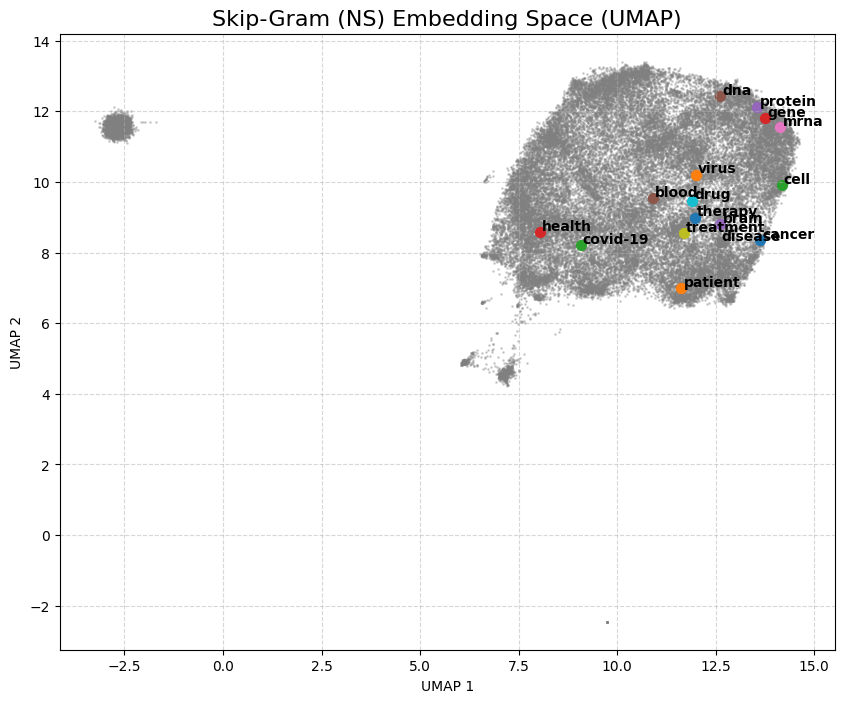

In [16]:

# --- 4-2. [실행] Skip-Gram 단독 분석 ---

# 분석할 어휘 목록
TARGET_WORDS = [
    'cancer', 'patient', 'cell', 'gene', 'protein', 'dna',
    'mrna', 'disease', 'treatment', 'drug', 'therapy',
    'virus', 'covid-19', 'health', 'brain', 'blood'
]

# 1. Vocab 및 임베딩 행렬 추출
sg_stoi = sg_datamodule.stoi
sg_itos = sg_datamodule.itos
sg_embeddings = sg_model.get_word_embedding()

# 2. 분석 1: 최근접 이웃 단어 (정성 평가)
print("--- [분석 1] 최근접 이웃 단어 (Cosine Similarity) ---")
for word in TARGET_WORDS:
    if word in sg_stoi:
        print(f"\n[Skip-Gram 결과]")
        find_nearest_neighbors(word, sg_embeddings, sg_stoi, sg_itos)
    else:
        print(f"\n[Info] '{word}'가 Vocab에 없습니다. (min_freq={MIN_FREQ})")

# 3. 분석 2: UMAP 2D 시각화
print("\n--- [분석 2] UMAP 2D 임베딩 시각화 ---")
visualize_embeddings_umap(
    sg_embeddings.numpy(),
    sg_itos,
    TARGET_WORDS,
    sg_stoi,
    "Skip-Gram (NS) Embedding Space (UMAP)"
)


In [17]:
# --- 4-3. [추가 분석] UMAP Outlier Cluster (떨어진 군집) 검사 ---

print("\n" + "="*50)
print("STEP 4-3: UMAP Outlier Cluster 검사")
print("="*50)

# UMAP 시각화와 동일한 로직으로 2D 임베딩을 다시 계산합니다.
# (STEP 4-1의 visualize_embeddings_umap 함수 로직을 그대로 가져옴)
try:
    # 1-1. 특수 토큰 제외
    valid_indices = [i for i, w in sg_itos.items() if w not in SPECIALS]
    valid_itos = {i: sg_itos[i] for i in valid_indices}
    matrix = sg_embeddings.numpy()[valid_indices]

    # 1-2. 스케일링
    matrix_scaled = StandardScaler().fit_transform(matrix)

    # 1-3. UMAP (시각화와 *동일한* 파라미터 사용)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, metric='cosine')
    embedding_2d = reducer.fit_transform(matrix_scaled)

    # 2. DataFrame으로 변환하여 필터링
    df_umap = pd.DataFrame(embedding_2d, columns=['umap1', 'umap2'])
    df_umap['word'] = list(valid_itos.values())

    # 3. Outlier 군집 필터링 (이미지 기반)
    # 이미지에서 메인 군집은 UMAP 2 값이 7.5 미만에, 떨어진 군집은 10~14 사이에 위치
    top_left_cluster = df_umap[df_umap['umap2'] > 10]

    if not top_left_cluster.empty:
        print(f"\n[분석] 좌측 상단 군집 (UMAP 2 > 10)에서 총 {len(top_left_cluster)}개의 단어가 발견되었습니다:")
        # 너무 많으면 일부만 출력
        print(top_left_cluster['word'].head(50).tolist())
    else:
        print("\n[분석] 좌측 상단 군집을 찾지 못했습니다.")

    # 4. (추가) 좌측 중간의 작은 군집도 확인 (UMAP 1 < -4)
    far_left_cluster = df_umap[(df_umap['umap1'] < -4) & (df_umap['umap2'] < 7.5)] # 메인 군집과 겹치지 않게

    if not far_left_cluster.empty:
        print(f"\n[분석] 좌측 중간 군집 (UMAP 1 < -4)에서 총 {len(far_left_cluster)}개의 단어가 발견되었습니다:")
        # 너무 많으면 일부만 출력
        print(far_left_cluster['word'].head(50).tolist())
    else:
        print("\n[분석] 좌측 중간 군집을 찾지 못했습니다.")

except Exception as e:
    print(f"Outlier 분석 중 오류 발생: {e}")
    print("이전 단계(STEP 4-2)의 변수(sg_itos, sg_embeddings 등)가 올바르게 생성되었는지 확인하세요.")



STEP 4-3: UMAP Outlier Cluster 검사


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



[분석] 좌측 상단 군집 (UMAP 2 > 10)에서 총 22573개의 단어가 발견되었습니다:
['analysis', 'model', 'effect', 'finding', 'potential', 'may', 'used', 'gene', 'system', 'also', 'role', 'protein', 'response', 'approach', 'showed', 'mechanism', 'identified', 'strategy', 'expression', 'function', 'activity', 'development', 'revealed', 'key', 'pathway', 'different', 'found', 'performance', 'process', 'sample', 'highlight', 'new', 'interaction', 'demonstrated', 'show', 'immune', 'stress', 'structure', 'target', 'specie', 'novel', 'molecular', 'complex', 'identify', 'well', 'provide', 'available', 'critical', 'via', 'understanding']

[분석] 좌측 중간 군집을 찾지 못했습니다.


In [18]:
# =============================================================================
# STEP 4 (추가 분석): K-Means 군집화 및 단어 유추(Analogy)
# =============================================================================
print("\n" + "="*50)
print("STEP 4 (추가 분석): K-Means 및 Analogy 시작")
print("="*50)

from sklearn.cluster import KMeans
from collections import defaultdict

# --- 4-3. [추가 분석 1] K-Means 군집화로 의미 그룹 찾기 ---
# UMAP/T-SNE는 '시각화'지만, K-Means는 실제로 단어들을 '그룹'으로 묶어줍니다.
print("\n--- [분석 3] K-Means 군집화 (자동 의미 그룹핑) ---")

try:
    # 1. UMAP과 동일하게 특수 토큰 제외 및 스케일링
    valid_indices = [i for i, w in sg_itos.items() if w not in SPECIALS]
    valid_itos_map = {i_new: sg_itos[i_old] for i_new, i_old in enumerate(valid_indices)}
    valid_stoi_map = {w: i for i, w in valid_itos_map.items()}
    matrix = sg_embeddings.numpy()[valid_indices]
    matrix_scaled = StandardScaler().fit_transform(matrix) # K-Means는 스케일링된 데이터 사용

    # 2. K-Means 실행 (K=30개 그룹으로 묶어보기)
    K = 30
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    kmeans.fit(matrix_scaled)
    cluster_labels = kmeans.labels_ # 각 단어가 속한 클러스터 번호 (0~29)

    # 3. 클러스터 결과 정리
    clusters = defaultdict(list)
    for i_new, word in valid_itos_map.items():
        cluster_id = cluster_labels[i_new]
        clusters[cluster_id].append(word)

    # 4. TARGET_WORDS가 어떤 그룹에 속했는지 확인
    print(f"K-Means (K={K}) 군집화 결과 (TARGET_WORDS 위치):")
    target_word_clusters = {}
    for word in TARGET_WORDS:
        if word in valid_stoi_map:
            i_new = valid_stoi_map[word]
            cluster_id = cluster_labels[i_new]
            target_word_clusters[word] = cluster_id
            print(f"  - '{word}' \t-> Cluster {cluster_id}")

    # 5. UMAP에서 가깝게 보였던 단어들이 같은 클러스터에 묶였는지 확인
    # 예: 'gene', 'dna', 'protein'이 같은 번호(Cluster ID)에 속했는지 확인
    print("\n[분석] UMAP에서 가깝던 단어들이 같은 Cluster ID에 속했는지 확인해보세요.")

    # 6. (샘플) 각 클러스터의 단어 10개씩 출력
    print("\n각 클러스터 샘플 단어 (10개):")
    for i in range(K):
        # 너무 긴 리스트는 잘라서 표시
        sample_words = clusters[i][:10]
        print(f"  Cluster {i} ({len(clusters[i])}개): {sample_words}")

except Exception as e:
    print(f"K-Means 분석 중 오류 발생: {e}")


# --- 4-4. [추가 분석 2] 단어 유추 (Word Analogy) ---
# Word2Vec의 꽃: A - B + C = D (예: king - man + woman = queen)
print("\n--- [분석 4] 단어 유추 (Word Analogy) ---")

@torch.no_grad()
def find_analogy(a, b, c, emb_matrix, stoi, itos, top_k=3):
    """ (b - a + c) 와 가장 유사한 단어 D를 찾습니다 (예: a=man, b=king, c=woman) """
    if not all(word in stoi for word in [a, b, c]):
        print(f"  [Error] '{a}', '{b}', '{c}' 중 Vocab에 없는 단어가 있습니다.")
        return

    # 1. 벡터 연산: vec(b) - vec(a) + vec(c)
    vec_a = emb_matrix[stoi[a]]
    vec_b = emb_matrix[stoi[b]]
    vec_c = emb_matrix[stoi[c]]
    target_vec = vec_b - vec_a + vec_c

    # 2. 타겟 벡터와 가장 유사한 단어 찾기 (최근접 이웃 로직 재사용)
    emb_matrix_norm = emb_matrix / (emb_matrix.norm(dim=1, keepdim=True) + 1e-9)
    target_vec_norm = target_vec / (target_vec.norm() + 1e-9)

    cos_sim = torch.matmul(emb_matrix_norm, target_vec_norm)

    # 3. 자기 자신(a, b, c)은 정답에서 제외
    cos_sim[stoi[a]] = -float('inf')
    cos_sim[stoi[b]] = -float('inf')
    cos_sim[stoi[c]] = -float('inf')

    # 4. 상위 K개 결과 출력
    top_k_vals, top_k_indices = torch.topk(cos_sim, k=top_k)

    print(f"\n  ▶ Analogy: {b} - {a} + {c} = ?")
    for i in range(top_k):
        word = itos[top_k_indices[i].item()]
        sim = top_k_vals[i].item()
        print(f"    {i+1}. {word} (Sim: {sim:.4f})")

try:
    # 1. 질병 -> 치료법 관계
    # patient(환자) - disease(질병) + drug(약물) = ? (치료받는 환자?)
    find_analogy('disease', 'patient', 'drug', sg_embeddings, sg_stoi, sg_itos)

    # 2. DNA -> RNA -> 단백질 (Central Dogma)
    # gene(유전자) - dna + mrna = ? (전사된 유전자?)
    find_analogy('dna', 'gene', 'mrna', sg_embeddings, sg_stoi, sg_itos)

    # 3. 바이러스 관련
    # virus(바이러스) - disease(질병) + health(건강) = ? (백신?)
    find_analogy('disease', 'virus', 'health', sg_embeddings, sg_stoi, sg_itos)

    # 4. 장기 관련
    # cell(세포) - blood(피) + brain(뇌) = ? (뇌세포?)
    find_analogy('blood', 'cell', 'brain', sg_embeddings, sg_stoi, sg_itos)

except Exception as e:
    print(f"Analogy 분석 중 오류 발생: {e}")

print("\n" + "="*50)
print("STEP 4 (추가 분석) 완료")
print("="*50)



STEP 4 (추가 분석): K-Means 및 Analogy 시작

--- [분석 3] K-Means 군집화 (자동 의미 그룹핑) ---
K-Means (K=30) 군집화 결과 (TARGET_WORDS 위치):
  - 'cancer' 	-> Cluster 18
  - 'patient' 	-> Cluster 2
  - 'cell' 	-> Cluster 28
  - 'gene' 	-> Cluster 9
  - 'protein' 	-> Cluster 17
  - 'dna' 	-> Cluster 9
  - 'mrna' 	-> Cluster 15
  - 'disease' 	-> Cluster 2
  - 'treatment' 	-> Cluster 7
  - 'drug' 	-> Cluster 7
  - 'therapy' 	-> Cluster 7
  - 'virus' 	-> Cluster 1
  - 'covid-19' 	-> Cluster 0
  - 'health' 	-> Cluster 21
  - 'brain' 	-> Cluster 16
  - 'blood' 	-> Cluster 4

[분석] UMAP에서 가깝던 단어들이 같은 Cluster ID에 속했는지 확인해보세요.

각 클러스터 샘플 단어 (10개):
  Cluster 0 (1252개): ['risk', 'associated', 'outcome', '95', 'ci', 'rate', 'mortality', 'survival', 'overall', 'prevalence']
  Cluster 1 (1156개): ['infection', 'resistance', 'strain', 'bacterial', 'virus', 'antibiotic', 'viral', 'antibody', 'pathogen', 'host']
  Cluster 2 (1671개): ['disease', 'case', 'patient', 'disorder', 'common', 'injury', 'severe', 'cause', 'chronic', 'a


STEP 4 (추가 분석 3): UMAP (Top 200 Words) 시작
--- [분석] UMAP (Top 200 Words) 시각화 시작 ---


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


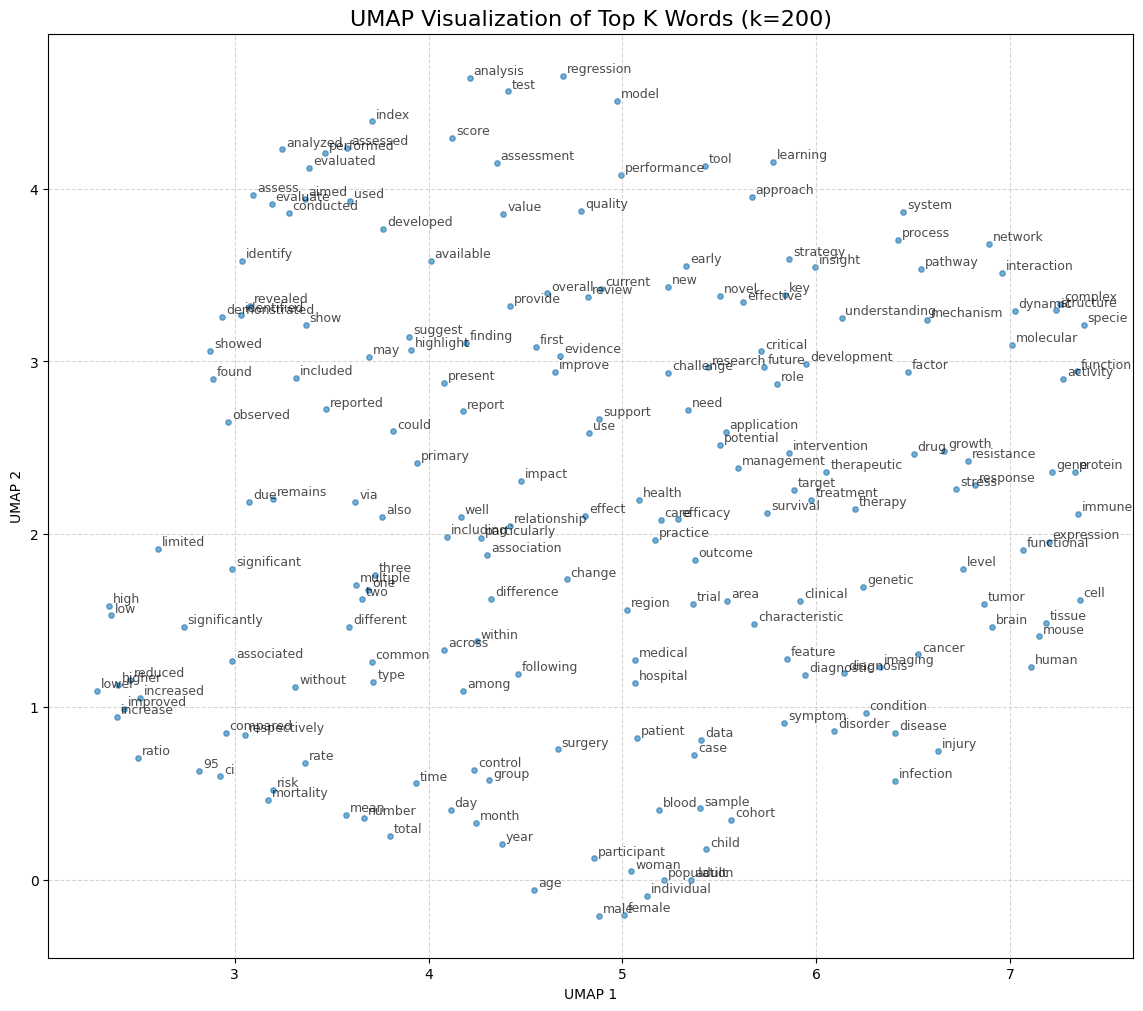


STEP 4 (추가 분석 3) 완료


In [22]:
# =============================================================================
# STEP 4 (추가 분석 3): 상위 K개 단어 UMAP 시각화
# =============================================================================
# 이 코드는 STEP 3에서 sg_embeddings, sg_itos 변수가 생성된 후에 실행해야 합니다.

print("\n" + "="*50)
print("STEP 4 (추가 분석 3): UMAP (Top 200 Words) 시작")
print("="*50)

# (NameError 방지) 이 셀만 따로 실행할 경우를 대비해 import
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap
from typing import List, Dict, Tuple

# (NameError 방지) 전역 변수
PAD, UNK = "<pad>", "<unk>"
SPECIALS = [PAD, UNK]


def visualize_top_k_words_umap(emb_matrix: torch.Tensor,
                               itos: Dict[int, str],
                               top_k: int = 200,
                               title: str = "UMAP Visualization of Top K Words"):
    """
    상위 K개 (가장 빈번한) 단어를 UMAP으로 시각화하고 모두 라벨링합니다.
    (SPECIALS 토큰 제외)
    """
    print(f"--- [분석] UMAP (Top {top_k} Words) 시각화 시작 ---")

    try:
        # 1. 상위 K개 단어의 인덱스와 임베딩을 선택합니다.
        #    itos는 이미 빈도순으로 정렬되어 있습니다 (0:PAD, 1:UNK)
        special_token_count = len(SPECIALS)

        if len(itos) < top_k + special_token_count:
            print(f"  [Warning] 요청한 K값({top_k})이 Vocab 크기보다 큽니다. K를 {len(itos) - special_token_count}로 조정합니다.")
            k = len(itos) - special_token_count
        else:
            k = top_k

        # SPECIALS 토큰(0, 1)을 제외하고 상위 k개 인덱스 선택 (예: 2 ~ 201)
        target_indices = list(range(special_token_count, special_token_count + k))
        target_words = [itos[i] for i in target_indices]

        # 2. 해당 단어들의 임베딩 행렬만 추출
        matrix = emb_matrix.numpy()[target_indices] # (k, D)

        # 3. 스케일링
        matrix_scaled = StandardScaler().fit_transform(matrix)

        # 4. UMAP (오직 k개 단어에 대해서만 실행)
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42, metric='cosine')
        embedding_2d = reducer.fit_transform(matrix_scaled)

        # 5. 시각화 (모든 k개 단어에 라벨 추가)
        plt.figure(figsize=(14, 12)) # 라벨을 표시하기 위해 캔버스 크기를 키웁니다.

        # 점 찍기
        plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=15, alpha=0.6)

        # 6. 모든 k개 단어에 텍스트 라벨 추가
        for i, word in enumerate(target_words):
            x, y = embedding_2d[i, 0], embedding_2d[i, 1]
            plt.text(x+0.02, y+0.02, word, fontsize=9, alpha=0.7) # 폰트 크기 조절

        plt.title(f"{title} (k={k})", fontsize=16)
        plt.xlabel("UMAP 1")
        plt.ylabel("UMAP 2")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    except Exception as e:
        print(f"Top K UMAP 시각화 중 오류 발생: {e}")

# --- [실행] ---
# (sg_embeddings와 sg_itos 변수가 이미 메모리에 로드되어 있어야 함)
visualize_top_k_words_umap(sg_embeddings, sg_itos, top_k=200)

print("\n" + "="*50)
print("STEP 4 (추가 분석 3) 완료")
print("="*50)


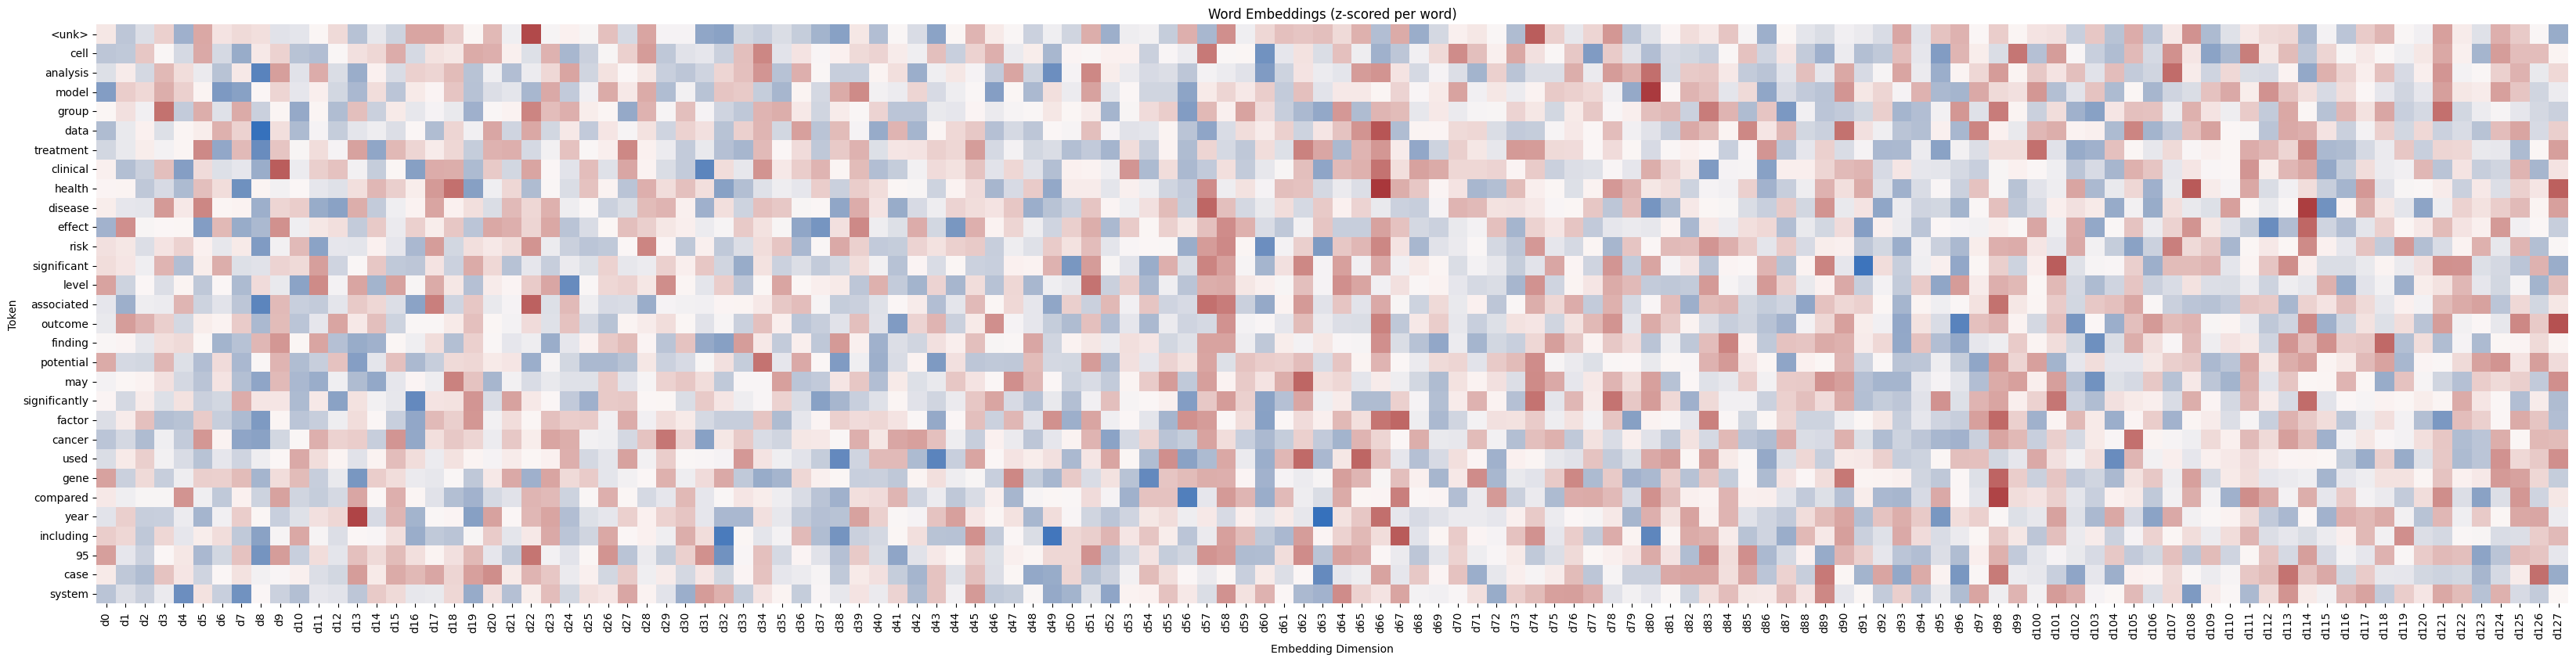

In [26]:
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple # visualize_embedding_heatmap에 필요

def _ensure_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def visualize_embedding_heatmap(itos: Dict[int, str],
                                emb_matrix: torch.Tensor,
                                target_tokens: List[str] = None,
                                top_k: int = None,
                                exclude_pad_idx: int = 0):
    """
    A) 단어 임베딩 값 히트맵 (행=단어, 열=임베딩 차원)
    - itos: dict {idx:int -> token:str}
    - emb_matrix: (V, D) 크기의 임베딩 텐서
    - target_tokens: 시각화할 토큰 리스트 (예: ['cell','protein','gene',...])
    - top_k: target_tokens를 주지 않으면, 사전 앞쪽에서 top_k개를 사용(패딩 제외)
    """
    E = _ensure_numpy(emb_matrix)     # (V, D)
    V, D = E.shape
    stoi = {tok: idx for idx, tok in itos.items()}

    # 대상 인덱스 선택
    if target_tokens:
        idxs = [stoi[tok] for tok in target_tokens if tok in stoi]
        labels = [itos[i] for i in idxs]
    else:
        # PAD(0) 같은 특수 토큰 제외하고 상위 몇 개
        # SPECIALS 리스트가 없으므로 exclude_pad_idx (기본값 0)만 사용
        candidates = [i for i in range(V) if i != exclude_pad_idx]
        if top_k is None:
            top_k = min(30, len(candidates))
        idxs = candidates[:top_k]
        labels = [itos[i] for i in idxs]

    if not labels:
        print("[Error] 시각화할 대상 토큰을 찾을 수 없습니다.")
        return

    mat = E[idxs]  # (N, D)

    # 정규화(선택): 각 단어 벡터 z-score → 차원별 스케일 차 완화
    mat_norm = (mat - mat.mean(axis=1, keepdims=True)) / (mat.std(axis=1, keepdims=True) + 1e-8)

    df = pd.DataFrame(mat_norm, index=labels, columns=[f"d{j}" for j in range(D)])

    plt.figure(figsize=(df.shape[0]*1.1, df.shape[1]*1.1))
    sns.heatmap(df, cmap="vlag", center=0, square=True, cbar=False)
    plt.title("Word Embeddings (z-scored per word)")
    plt.xlabel("Embedding Dimension")
    plt.ylabel("Token")
    plt.tight_layout()
    plt.show()

# --- 실행 코드 (변수명 수정) ---
# 이전에 학습시킨 'sg_model'과 'sg_datamodule' 변수를 사용합니다.

emb_matrix = sg_model.get_word_embedding()
stoi = sg_datamodule.stoi
itos = sg_datamodule.itos

visualize_embedding_heatmap(itos, emb_matrix, top_k=30)

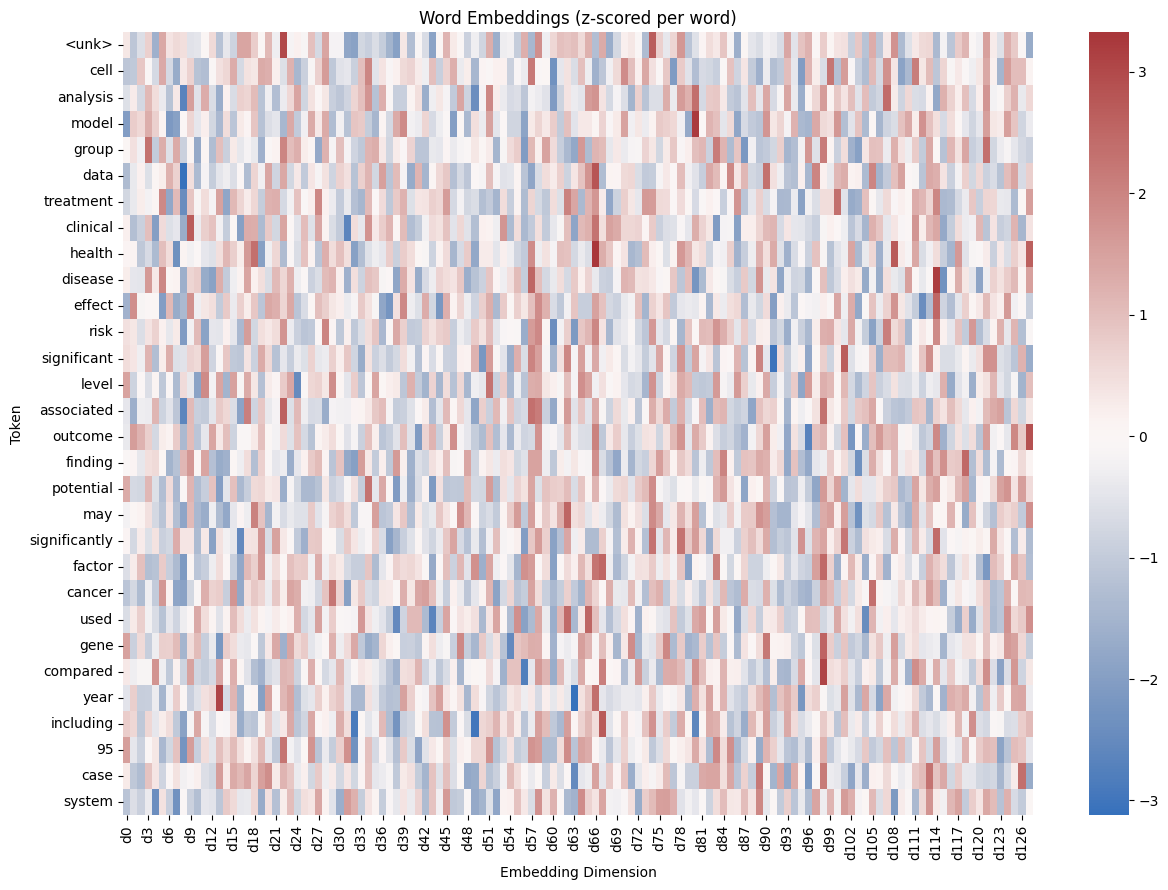

In [27]:
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple # visualize_embedding_heatmap에 필요

def _ensure_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def visualize_embedding_heatmap(itos: Dict[int, str],
                                emb_matrix: torch.Tensor,
                                target_tokens: List[str] = None,
                                top_k: int = None,
                                exclude_pad_idx: int = 0):
    """
    A) 단어 임베딩 값 히트맵 (행=단어, 열=임베딩 차원)
    - itos: dict {idx:int -> token:str}
    - emb_matrix: (V, D) 크기의 임베딩 텐서
    - target_tokens: 시각화할 토큰 리스트 (예: ['cell','protein','gene',...])
    - top_k: target_tokens를 주지 않으면, 사전 앞쪽에서 top_k개를 사용(패딩 제외)
    """
    E = _ensure_numpy(emb_matrix)     # (V, D)
    V, D = E.shape
    stoi = {tok: idx for idx, tok in itos.items()}

    # 대상 인덱스 선택
    if target_tokens:
        idxs = [stoi[tok] for tok in target_tokens if tok in stoi]
        labels = [itos[i] for i in idxs]
    else:
        # PAD(0) 같은 특수 토큰 제외하고 상위 몇 개
        # SPECIALS 리스트가 없으므로 exclude_pad_idx (기본값 0)만 사용
        candidates = [i for i in range(V) if i != exclude_pad_idx]
        if top_k is None:
            top_k = min(30, len(candidates))
        idxs = candidates[:top_k]
        labels = [itos[i] for i in idxs]

    if not labels:
        print("[Error] 시각화할 대상 토큰을 찾을 수 없습니다.")
        return

    mat = E[idxs]  # (N, D)

    # 정규화(선택): 각 단어 벡터 z-score → 차원별 스케일 차 완화
    mat_norm = (mat - mat.mean(axis=1, keepdims=True)) / (mat.std(axis=1, keepdims=True) + 1e-8)

    df = pd.DataFrame(mat_norm, index=labels, columns=[f"d{j}" for j in range(D)])

    # 그림 크기 동적 조절
    plt.figure(figsize=(max(12, D * 0.1), max(8, len(labels) * 0.3)))
    sns.heatmap(df, cmap="vlag", center=0, cbar=True) # cbar=True로 변경 (원본과 동일하게)
    plt.title("Word Embeddings (z-scored per word)")
    plt.xlabel("Embedding Dimension")
    plt.ylabel("Token")
    plt.tight_layout()
    plt.show()

# --- 실행 코드 (변수명 수정) ---
# 이전에 학습시킨 'sg_model'과 'sg_datamodule' 변수를 사용합니다.

emb_matrix = sg_model.get_word_embedding()
stoi = sg_datamodule.stoi
itos = sg_datamodule.itos

visualize_embedding_heatmap(itos, emb_matrix, top_k=30)